# Moodsic — E2E Video to Fusion + Song Match Without Clustering

Run the PERCEIVE pipeline on a video. It detects a primary face per
frame (if any), predicts valence/arousal from scene and face, fuses
them (uncertainty‑aware), and draws an overlay.

Flow:
- Run Setup and Adapters.
- Optionally skim the Helpers.
- In the Experiment cell, set `VIDEO_PATH` and run.

Outputs:
- Time series plot of fused valence/arousal.
- Sample overlays (first and last processed frames).
- Optional: save a full overlay video.


This notebook extends the video fusion demo with MATCH-stage song recommendations.

In [1]:
# Setup: repo path + imports

import os, sys, math, time

from pathlib import Path

repo_root = Path.cwd()

if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np

try:
    import cv2
except Exception as e:
    raise RuntimeError(f'OpenCV (cv2) is required: {e}')
import matplotlib.pyplot as plt

from utils.runtime_driver import VideoPerceptionResult, perceive_video
print('Repo root:', repo_root)



Repo root: /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO


In [2]:
# Adapters (best‑effort): try both scene and face paths
scene_adapter = None
face_processor = None
face_adapter = None

try:
    from models.scene.clip_vit_scene_adapter import SceneCLIPAdapter
    scene_adapter = SceneCLIPAdapter(
        model_name='openai/clip-vit-base-patch32',
        dropout_rate=0.3,
        device='auto',
        tta=3,
    )
    print('SceneCLIPAdapter: OK')
except Exception as e:
    print(f'SceneCLIPAdapter unavailable (transformers/weights/device): {e}')

try:
    from utils.emonet_single_face_processor import EmoNetSingleFaceProcessor
    face_processor = EmoNetSingleFaceProcessor(min_detection_confidence=0.5, padding_ratio=0.2)
    print('Face processor:', 'available' if getattr(face_processor, 'available', False) else 'unavailable')
except Exception as e:
    print(f'Face processor unavailable (mediapipe missing?): {e}')

try:
    from models.face.emonet_adapter import EmoNetAdapter
    face_adapter = EmoNetAdapter(
        ckpt_dir='models/emonet/pretrained',
        n_classes=8,
        device='auto',
        tta=3,
        calibration_checkpoint=None,
    )
    print('EmoNetAdapter: OK')
except Exception as e:
    print(f'EmoNetAdapter unavailable (torch/weights/device): {e}')


SceneCLIPAdapter: failed torch.load on /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO/scene/checkpoints/clip_vit-b32_model_improved_learner.pkl: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL fastai.learner.Learner was not an allowed global by default. Please use `torch.serialization.add_safe_globals([fastai.learner.Learner])` or the `torch.serialization.safe_globals([fastai.learner.Learner])` context manager to a

SceneCLIPAdapter: OK
Face processor: available
EmoNetAdapter: OK


I0000 00:00:1759560700.831808 22111683 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1759560700.846998 22111941 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## EXPERIMENTATION

Instructions:
- Set `VIDEO_PATH` (absolute or repo‑relative).
- Adjust `SCENE_TTA`/`FACE_TTA`, `TARGET_SAMPLE_FPS`, and toggles as needed.
- Run the cell: `perceive_video(...)` handles frame iteration, overlays, and plots fused V/A.
- Optionally set `SAVE_OVERLAY_VIDEO=True` to save an annotated MP4.

Notes:
- TTA increases runtime roughly linearly; 3–5 is a good start.
- Stabilizer holds updates when fused variance is high; helps reduce jitter.


## Stabilization = False

In [3]:
## Experiment: set the video and run

#VIDEO_PATH = 'data/videos/94.mp4'  # set to your video

## Runtime/config
#SCENE_TTA = 3
#FACE_TTA = 3
#USE_VARIANCE_WEIGHTING = True
#ENABLE_STABILIZER = False
#UNCERTAINTY_THRESHOLD = 0.4
#STABILIZER_WINDOW = 60
#TARGET_SAMPLE_FPS = 1.0      # desired processed frames per second
#MAX_FRAMES = None           # e.g., 600 to cap processing

## Overlay video output (optional)
#SAVE_OVERLAY_VIDEO = False
#OVERLAY_OUT = 'outputs/overlay_fusion.mp4'

#src = Path(VIDEO_PATH)
#if not src.exists():
#    alt = repo_root / VIDEO_PATH
#    if alt.exists():
#        src = alt

#result = perceive_video(
#    src,
#    scene_predictor=scene_adapter,
#    face_processor=face_processor,
#    face_expert=face_adapter,
#    scene_tta=SCENE_TTA,
#    face_tta=FACE_TTA,
#    target_sample_fps=TARGET_SAMPLE_FPS,
#    max_frames=MAX_FRAMES,
#    use_variance_weighting=USE_VARIANCE_WEIGHTING,
#    enable_stabilizer=ENABLE_STABILIZER,
#    uncertainty_threshold=UNCERTAINTY_THRESHOLD,
#    stabilizer_window=STABILIZER_WINDOW,
#    save_overlay_to=OVERLAY_OUT if SAVE_OVERLAY_VIDEO else None,
#)

#frame_total = result.frame_count if result.frame_count is not None else 'unknown'
#print(
#    f"Video opened: {result.video_path} ({result.width}x{result.height} @ {result.fps:.2f} fps, frames≈{frame_total})"
#)
#print(f'Processed frames: {result.processed_frames}')
#print(f'Sampling stride: {result.sample_stride} (effective ≈ {result.effective_fps:.2f} fps)')

#def _show_stats(name, series):
#    print(f'----- {name} -----')
#    print(f"Mean valence: {series.mean_valence}")
#    print(f"Mean arousal: {series.mean_arousal}")
#    print(f"Median valence: {series.median_valence}")
#    print(f"Median arousal: {series.median_arousal}")
#    print(f"Mode valence: {series.mode_valence}")
#    print(f"Mode arousal: {series.mode_arousal}")

#_show_stats('Fusion', result.fusion_result)
#_show_stats('Scene', result.scene_result)
#_show_stats('Face', result.face_result)
#if result.overlay_path:
#    print(f'Overlay video saved to: {result.overlay_path}')

#first_overlay, last_overlay = result.first_overlay, result.last_overlay

#fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#if first_overlay is not None:
#    axes[0].imshow(cv2.cvtColor(first_overlay, cv2.COLOR_BGR2RGB))
#    axes[0].set_title('First overlay')
#    axes[0].axis('off')
#if last_overlay is not None:
#    axes[1].imshow(cv2.cvtColor(last_overlay, cv2.COLOR_BGR2RGB))
#    axes[1].set_title('Last overlay')
#    axes[1].axis('off')
#plt.tight_layout(); plt.show()

#if result.valence:
#    sample_indices = np.arange(len(result.frame_indices), dtype=int)
#    vals = np.array(result.valence, dtype=float)
#    aros = np.array(result.arousal, dtype=float)
#    vvars = np.array(result.var_valence, dtype=float)
#    avars = np.array(result.var_arousal, dtype=float)

#    plt.figure(figsize=(12, 3))
#    plt.plot(sample_indices, vals, label='valence', color='tab:blue')
#    plt.plot(sample_indices, aros, label='arousal', color='tab:orange')
#    plt.xlabel('sample index')
#    plt.ylabel('value [-1, 1]')
#    plt.ylim(-1.05, 1.05)
#    plt.grid(True, alpha=0.2)
#    plt.legend()
#    plt.tight_layout(); plt.show()

#    if not (np.isnan(vvars).all() and np.isnan(avars).all()):
#        plt.figure(figsize=(12, 2.2))
#        plt.plot(sample_indices, vvars, label='var(valence)', color='tab:blue', alpha=0.6)
#        plt.plot(sample_indices, avars, label='var(arousal)', color='tab:orange', alpha=0.6)
#        plt.xlabel('sample index')
#        plt.ylabel('variance')
#        plt.yscale('log')
#        plt.grid(True, which='both', alpha=0.2)
#        plt.legend(); plt.tight_layout(); plt.show()
#else:
#    print('No frames processed; check VIDEO_PATH or adapters availability.')


## Stabilization = True

I0000 00:00:1759560701.343741 22111683 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1759560701.345314 22112022 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Video opened: /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO/data/videos/94.mp4 (1280x720 @ 25.00 fps, frames≈2064)
Processed frames: 83
Sampling stride: 25 (effective ≈ 1.00 fps)
----- Fusion -----
Mean valence: -0.2421576138218268
Mean arousal: 0.06108264176093451
Median valence: -0.22631678516106346
Median arousal: 0.09122089574925937
Mode valence: -0.4639311730861664
Mode arousal: 0.17693551791713763
----- Scene -----
Mean valence: -0.41931895762878324
Mean arousal: -0.2830728369215167
Median valence: -0.4253768026828766
Median arousal: -0.2911487817764282
Mode valence: -0.4639311730861664
Mode arousal: 0.3341193199157715
----- Face -----
Mean valence: -0.057876897916301254
Mean arousal: 0.24123669114320634
Median valence: -0.12607062018165985
Median arousal: 0.22413773089647293
Mode valence: -0.19071654975414276
Mode arousal: 0.18474838137626648


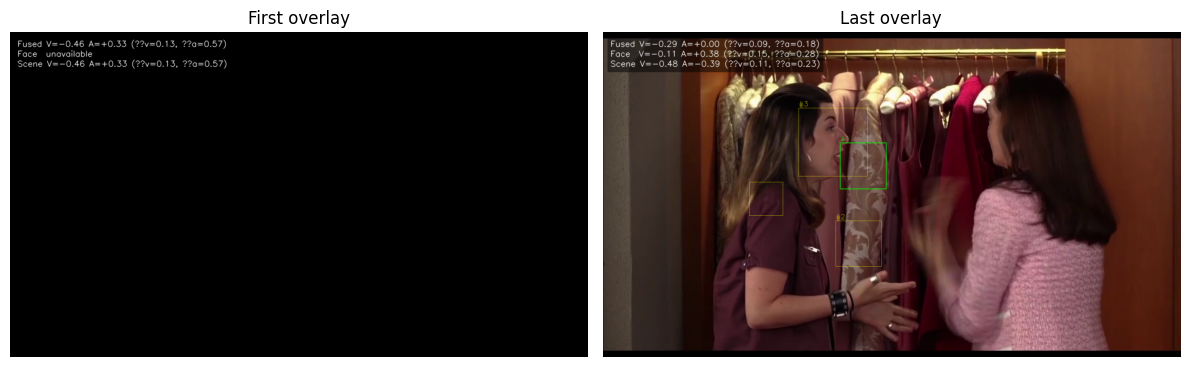

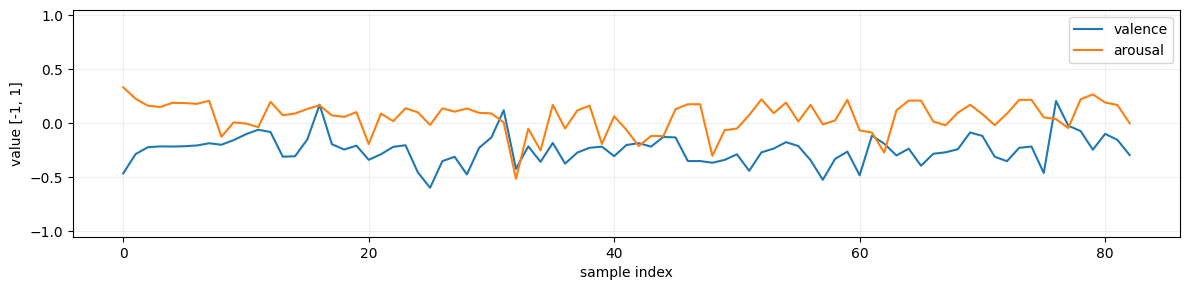

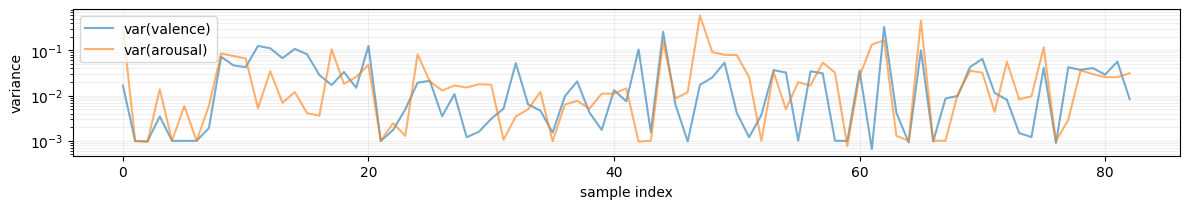

In [4]:
# Experiment: set the video and run

VIDEO_PATH = 'data/videos/94.mp4'  # set to your video

# Runtime/config
SCENE_TTA = 3
FACE_TTA = 3
USE_VARIANCE_WEIGHTING = True
ENABLE_STABILIZER = True
UNCERTAINTY_THRESHOLD = 0.4
STABILIZER_WINDOW = 60
TARGET_SAMPLE_FPS = 1.0      # desired processed frames per second
MAX_FRAMES = None           # e.g., 600 to cap processing

# Overlay video output (optional)
SAVE_OVERLAY_VIDEO = False
OVERLAY_OUT = 'outputs/overlay_fusion.mp4'

src = Path(VIDEO_PATH)
if not src.exists():
    alt = repo_root / VIDEO_PATH
    if alt.exists():
        src = alt

result = perceive_video(
    src,
    scene_predictor=scene_adapter,
    face_processor=face_processor,
    face_expert=face_adapter,
    scene_tta=SCENE_TTA,
    face_tta=FACE_TTA,
    target_sample_fps=TARGET_SAMPLE_FPS,
    max_frames=MAX_FRAMES,
    use_variance_weighting=USE_VARIANCE_WEIGHTING,
    enable_stabilizer=ENABLE_STABILIZER,
    uncertainty_threshold=UNCERTAINTY_THRESHOLD,
    stabilizer_window=STABILIZER_WINDOW,
    save_overlay_to=OVERLAY_OUT if SAVE_OVERLAY_VIDEO else None,
)

frame_total = result.frame_count if result.frame_count is not None else 'unknown'
print(
    f"Video opened: {result.video_path} ({result.width}x{result.height} @ {result.fps:.2f} fps, frames≈{frame_total})"
)

print(f'Processed frames: {result.processed_frames}')
print(f'Sampling stride: {result.sample_stride} (effective ≈ {result.effective_fps:.2f} fps)')

def _show_stats(name, series):
    print(f'----- {name} -----')
    print(f"Mean valence: {series.mean_valence}")
    print(f"Mean arousal: {series.mean_arousal}")
    print(f"Median valence: {series.median_valence}")
    print(f"Median arousal: {series.median_arousal}")
    print(f"Mode valence: {series.mode_valence}")
    print(f"Mode arousal: {series.mode_arousal}")

_show_stats('Fusion', result.fusion_result)
_show_stats('Scene', result.scene_result)
_show_stats('Face', result.face_result)
if result.overlay_path:
    print(f'Overlay video saved to: {result.overlay_path}')

first_overlay, last_overlay = result.first_overlay, result.last_overlay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if first_overlay is not None:
    axes[0].imshow(cv2.cvtColor(first_overlay, cv2.COLOR_BGR2RGB))
    axes[0].set_title('First overlay')
    axes[0].axis('off')
if last_overlay is not None:
    axes[1].imshow(cv2.cvtColor(last_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Last overlay')
    axes[1].axis('off')
plt.tight_layout(); plt.show()

if result.valence:
    sample_indices = np.arange(len(result.frame_indices), dtype=int)
    vals = np.array(result.valence, dtype=float)
    aros = np.array(result.arousal, dtype=float)
    vvars = np.array(result.var_valence, dtype=float)
    avars = np.array(result.var_arousal, dtype=float)

    plt.figure(figsize=(12, 3))
    plt.plot(sample_indices, vals, label='valence', color='tab:blue')
    plt.plot(sample_indices, aros, label='arousal', color='tab:orange')
    plt.xlabel('sample index')
    plt.ylabel('value [-1, 1]')
    plt.ylim(-1.05, 1.05)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout(); plt.show()

    if not (np.isnan(vvars).all() and np.isnan(avars).all()):
        plt.figure(figsize=(12, 2.2))
        plt.plot(sample_indices, vvars, label='var(valence)', color='tab:blue', alpha=0.6)
        plt.plot(sample_indices, avars, label='var(arousal)', color='tab:orange', alpha=0.6)
        plt.xlabel('sample index')
        plt.ylabel('variance')
        plt.yscale('log')
        plt.grid(True, which='both', alpha=0.2)
        plt.legend(); plt.tight_layout(); plt.show()
else:
    print('No frames processed; check VIDEO_PATH or adapters availability.')



## MATCH: Load Song Matcher

Configure the DEAM song catalogue and matcher artifacts. Adjust the paths
below if you keep the parquet or GMM files elsewhere.


In [5]:

from utils.song_matcher import SongMatcher
import pandas as pd

SONGS_PARQUET = repo_root / "notebooks" / "deam" / "artifacts" / "deam_gmm" / "deam_songs.parquet"
ARTIFACTS_DIR = repo_root / "notebooks" / "deam" / "artifacts" / "deam_gmm"
SCALER_FILE = ARTIFACTS_DIR / "scaler.pkl"
GMM_FILE = ARTIFACTS_DIR / "gmm.pkl"

if not SONGS_PARQUET.exists():
    raise FileNotFoundError(f"Songs table not found: {SONGS_PARQUET}. Update SONGS_PARQUET to your location.")
if not SCALER_FILE.exists() or not GMM_FILE.exists():
    raise FileNotFoundError(
        "SongMatcher artifacts missing. Ensure 'scaler.pkl' and 'gmm.pkl' exist in ARTIFACTS_DIR"
    )

try:
    songs_df = pd.read_parquet(SONGS_PARQUET)
except Exception as exc:
    raise RuntimeError(
        "Failed to load songs parquet. Install pyarrow/fastparquet or verify the file."
    ) from exc

print(f"Loaded {len(songs_df)} songs from {SONGS_PARQUET}")

song_matcher = SongMatcher.from_artifacts(
    songs_df,
    ARTIFACTS_DIR,
    min_dwell_time=0.0,
    recent_k=8,
    top2_threshold=0.55,
)
song_matcher.reset()
print("Song matcher ready.")


Loaded 1802 songs from /Users/kevinmanuel/Documents/NUS-Project-Sem2/REPO/notebooks/deam/artifacts/deam_gmm/deam_songs.parquet


/opt/anaconda3/envs/p312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Song matcher ready.


/opt/anaconda3/envs/p312/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



## MATCH: Recommend a Song

Use the fused valence/arousal to retrieve a song. Run the PERCEIVE cell above
first so the `result` variable is populated.


In [6]:

if 'result' not in locals():
    raise RuntimeError("Run the PERCEIVE experiment cell first to populate `result`.")
if result.processed_frames == 0:
    raise RuntimeError("No frames were processed; unable to recommend a song.")

fused_mean_val = result.fusion_result.mean_valence
fused_mean_aro = result.fusion_result.mean_arousal

if fused_mean_val is None or fused_mean_aro is None:
    import numpy as np

    vals = np.asarray(result.fusion_result.valence, dtype=float)
    aros = np.asarray(result.fusion_result.arousal, dtype=float)
    mask = np.isfinite(vals) & np.isfinite(aros)
    if not mask.any():
        raise RuntimeError("Fusion result missing finite valence/arousal values.")
    fused_mean_val = float(vals[mask].mean())
    fused_mean_aro = float(aros[mask].mean())

song_matcher.reset()
match = song_matcher.recommend(fused_mean_val, fused_mean_aro, now=0.0)
print(f"Target fused V/A (mean): {fused_mean_val:.3f}, {fused_mean_aro:.3f}")

if match.song is None:
    print("Song matcher did not return a song.")
else:
    song = match.song
    print("Recommended song:")
    preferred_fields = ["song_id", "song_title", "artist", "cluster", "valence_ref", "arousal_ref"]
    for field in preferred_fields:
        if field in song.index:
            print(f"  {field}: {song[field]}")
    missing = [field for field in preferred_fields if field not in song.index]
    if missing:
        print("  (Missing columns:", ", ".join(missing), ")")


Target fused V/A (mean): -0.242, 0.061
Recommended song:
  song_id: 789
  song_title: No Slow Dancing
  artist: Austin Leonard Jones
  cluster: 3
  valence_ref: -0.275
  arousal_ref: 0.050000000000000044



### Optional: Inspect Top Candidates

View the closest songs in valence/arousal space for the current target.


In [7]:

import numpy as np
import pandas as pd
from IPython.display import display

def top_candidates(matcher: SongMatcher, v_ref: float, a_ref: float, n: int = 5) -> pd.DataFrame:
    df = matcher.songs.copy()
    coords = df[[matcher.valence_col, matcher.arousal_col]].to_numpy(dtype=float)
    target = np.array([v_ref, a_ref], dtype=float)
    distances = np.linalg.norm(coords - target, axis=1)
    df = df.assign(distance=distances)
    return df.sort_values('distance').head(n)

if match.song is not None:
    top_df = top_candidates(song_matcher, fused_mean_val, fused_mean_aro, n=5)
    display(top_df.reset_index(drop=True))
else:
    print("No recommendation available to list candidates.")


,song_id,valence_ref,arousal_ref,artist,song_title,genre,cluster,cluster_conf,distance
0,789,-0.275,0.050,Austin Leonard Jones,No Slow Dancing,pop,3,0.858174,0.034662
1,49,-0.275,0.075,The Agrarians,Our Nights on the Turnpike,blues/soul,3,0.872255,0.035670
2,1986,-0.250,0.025,Nine Inch Nails,Echoplex,rock,3,0.820628,0.036925
3,342,-0.250,0.025,Jason Shaw,ACOUSTIC MEDITATION,folk/country,3,0.820628,0.036925
4,298,-0.250,0.100,Moore & Sons,Obvious,folk/country,3,0.856063,0.039700
